=== HOUSING ===
(200, 3)
dien_tich    0
gia          0
so_phong     0
dtype: int64
         dien_tich            gia    so_phong
count   200.000000     200.000000  200.000000
mean    111.809266    1757.923653    3.780000
std     153.218531    7799.284808    3.902274
min       0.000000       1.000000    0.000000
25%      71.371015     818.248739    2.000000
50%     100.362307    1023.651805    3.000000
75%     120.617439    1206.169342    5.000000
max    2000.000000  100000.000000   50.000000


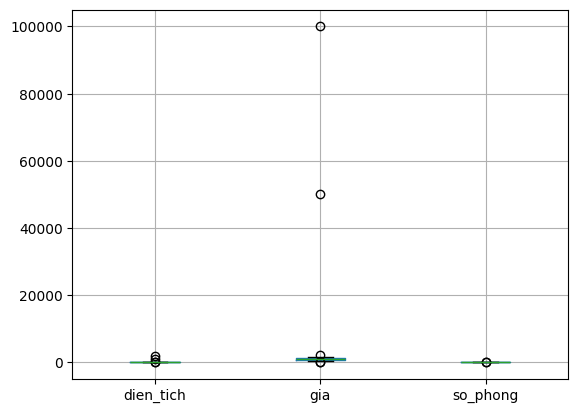

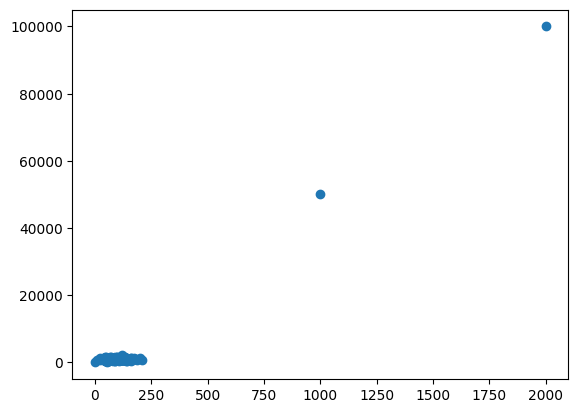

IQR outliers: 7
Z-score outliers: 2


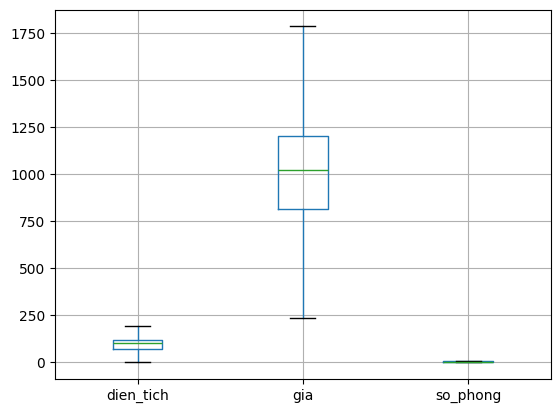

=== IOT ===
sensor_id      0
temperature    0
pressure       0
humidity       0
dtype: int64


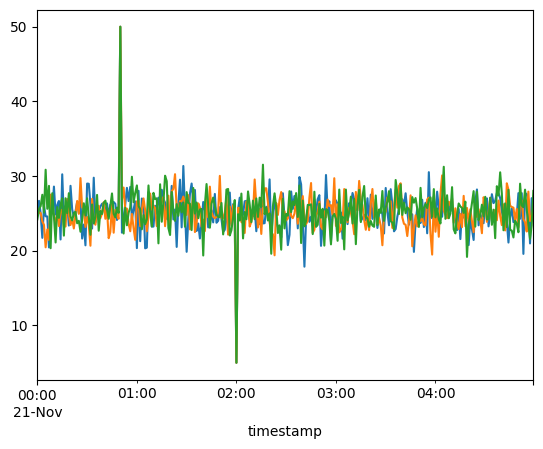

Rolling outliers: 0
Z-score outliers: 13


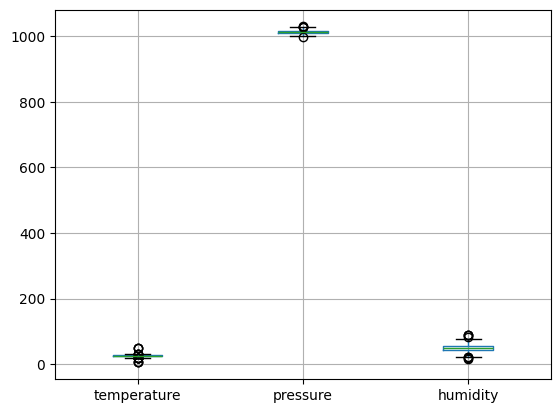

/tmp/ipykernel_11168/2042370278.py:68: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  iot_clean = iot.interpolate()


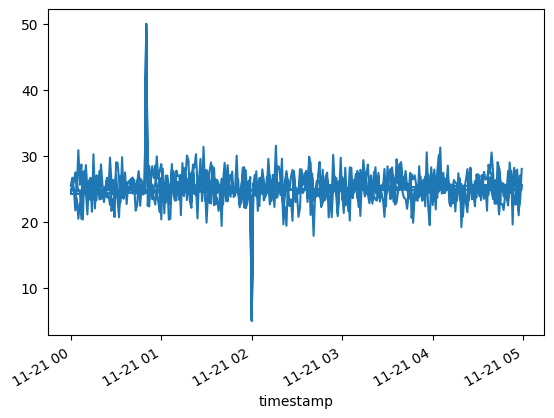

=== ECOMMERCE ===
price       0
quantity    0
rating      0
category    0
dtype: int64
              price    quantity      rating
count    300.000000  300.000000  300.000000
mean      99.019136    2.943333    3.126100
std      641.145776    6.357267    1.242498
min        0.000000    0.000000    1.006575
25%       36.875825    1.000000    2.105117
50%       49.144452    2.000000    3.144016
75%       64.920091    3.000000    4.038819
max    10000.000000  100.000000   10.000000


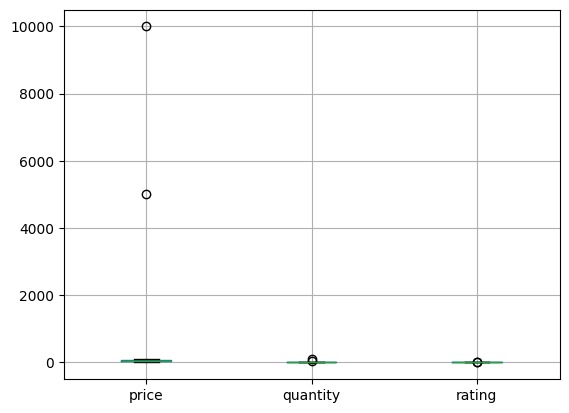

IQR outliers: 4


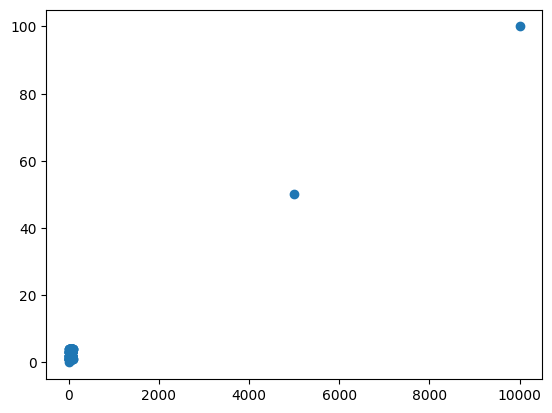

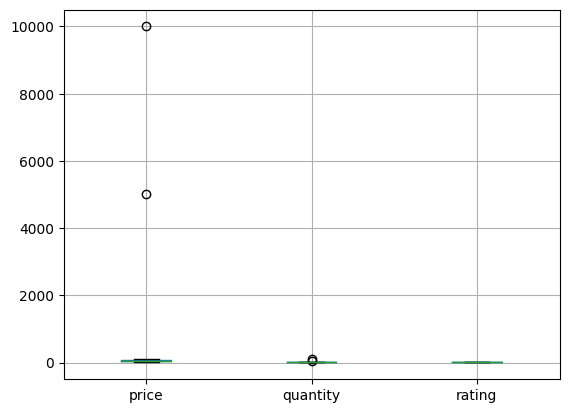

=== MULTIVARIATE ===


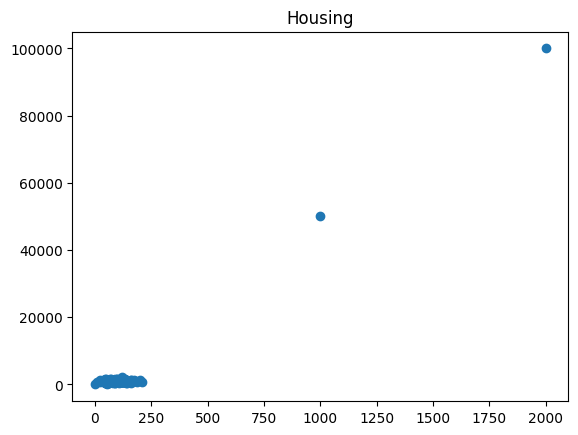

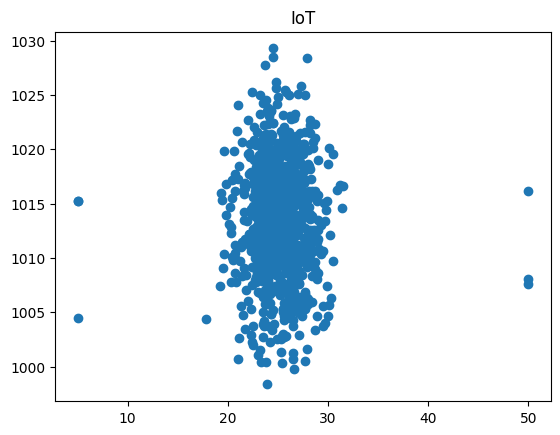

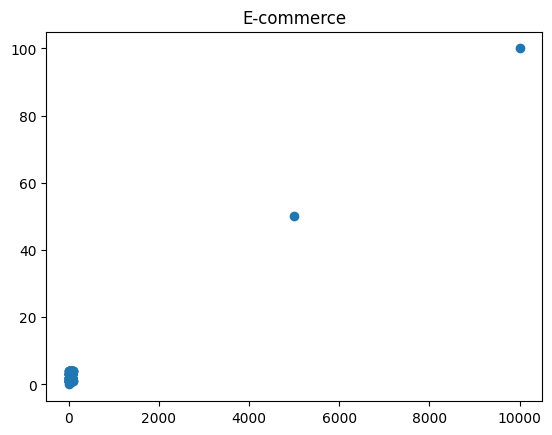

In [1]:
# ===== IMPORT =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD DATA =====
housing = pd.read_csv('ITA105_Lab_2_Housing.csv')
ecom = pd.read_csv('ITA105_Lab_2_Ecommerce.csv')
iot = pd.read_csv('ITA105_Lab_2_Iot.csv')


# ================== BÀI 1: HOUSING ==================
print("=== HOUSING ===")
print(housing.shape)
print(housing.isnull().sum())
print(housing.describe())

housing.boxplot()
plt.show()

plt.scatter(housing['dien_tich'], housing['gia'])
plt.show()

Q1 = housing.quantile(0.25)
Q3 = housing.quantile(0.75)
IQR = Q3 - Q1

out_iqr = housing[((housing < (Q1 - 1.5*IQR)) | (housing > (Q3 + 1.5*IQR))).any(axis=1)]
print("IQR outliers:", len(out_iqr))

z = np.abs((housing - housing.mean()) / housing.std())
out_z = housing[(z > 3).any(axis=1)]
print("Z-score outliers:", len(out_z))

housing_clean = housing.clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR, axis=1)
housing_clean.boxplot()
plt.show()


# ================== BÀI 2: IOT ==================
print("=== IOT ===")
iot['timestamp'] = pd.to_datetime(iot['timestamp'])
iot = iot.set_index('timestamp')

print(iot.isnull().sum())

iot.groupby('sensor_id')['temperature'].plot(legend=False)
plt.show()

rolling_mean = iot['temperature'].rolling(10).mean()
rolling_std = iot['temperature'].rolling(10).std()

upper = rolling_mean + 3*rolling_std
lower = rolling_mean - 3*rolling_std

out_roll = iot[(iot['temperature'] > upper) | (iot['temperature'] < lower)]
print("Rolling outliers:", len(out_roll))

z = np.abs((iot[['temperature','pressure','humidity']] - iot[['temperature','pressure','humidity']].mean()) /
           iot[['temperature','pressure','humidity']].std())

out_z = iot[(z > 3).any(axis=1)]
print("Z-score outliers:", len(out_z))

iot[['temperature','pressure','humidity']].boxplot()
plt.show()

iot_clean = iot.interpolate()
iot_clean['temperature'].plot()
plt.show()


# ================== BÀI 3: ECOMMERCE ==================
print("=== ECOMMERCE ===")
print(ecom.isnull().sum())
print(ecom.describe())

ecom[['price','quantity','rating']].boxplot()
plt.show()

Q1 = ecom[['price','quantity','rating']].quantile(0.25)
Q3 = ecom[['price','quantity','rating']].quantile(0.75)
IQR = Q3 - Q1

out_iqr = ecom[((ecom[['price','quantity','rating']] < (Q1 - 1.5*IQR)) |
                 (ecom[['price','quantity','rating']] > (Q3 + 1.5*IQR))).any(axis=1)]
print("IQR outliers:", len(out_iqr))

plt.scatter(ecom['price'], ecom['quantity'])
plt.show()

ecom_clean = ecom[(ecom['price'] > 0) & (ecom['rating'] <= 5)]
ecom_clean[['price','quantity','rating']].boxplot()
plt.show()


# ================== BÀI 4: MULTIVARIATE ==================
print("=== MULTIVARIATE ===")

plt.scatter(housing['dien_tich'], housing['gia'])
plt.title("Housing")
plt.show()

plt.scatter(iot['temperature'], iot['pressure'])
plt.title("IoT")
plt.show()

plt.scatter(ecom['price'], ecom['quantity'])
plt.title("E-commerce")
plt.show()